<a href="https://colab.research.google.com/github/Valentinekrafft/Machinelearningproject/blob/main/ML_1.2_good.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from google.colab import files
import io

In [2]:
uploaded = files.upload("ML22-result.csv")
filename = list(uploaded.keys())[0]
df= pd.read_csv(io.BytesIO(uploaded[filename]))

# View the first few rows
df.head()

Saving ML_22-result.csv to ML22-result.csv/ML_22-result.csv


,source_id,ra,dec,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,parallax_over_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,bp_g,g_rp,ruwe,teff_gspphot,logg_gspphot,mh_gspphot
0,2199023259904,45.095579,0.085306,5.077848,0.203319,-11.971485,0.179211,0.076866,0.181155,0.424312,18.248137,18.634357,17.672672,0.961685,0.386221,0.575464,1.169010,5140.7130,4.7890,-1.5232
1,4707284223104,44.898461,0.117979,1.256026,0.211785,-1.084036,0.177564,0.062954,0.185668,0.339066,18.714731,19.018673,18.222942,0.795731,0.303942,0.491789,0.956716,5545.0024,4.7531,-1.7056
2,5291399871488,44.922856,0.151158,-4.819578,0.122073,-17.370913,0.093270,1.241905,0.099930,12.427738,17.489523,18.389256,16.583426,1.805830,0.899733,0.906097,1.104422,4001.4219,4.7637,-0.5103
3,7116761616256,45.000073,0.214145,45.326016,0.136484,-52.869739,0.099320,5.184997,0.116107,44.656930,16.743837,18.321789,15.483147,2.838642,1.577951,1.260691,1.666492,3431.9377,4.8043,0.0664
4,12678743467776,45.278127,0.316619,7.354026,0.223697,-7.386780,0.222060,0.110442,0.256736,0.430177,18.761465,19.237932,18.232374,1.005558,0.476467,0.529091,1.000386,5245.1143,4.7829,-1.6568


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   source_id            500000 non-null  int64  
 1   ra                   500000 non-null  float64
 2   dec                  500000 non-null  float64
 3   pmra                 500000 non-null  float64
 4   pmra_error           500000 non-null  float64
 5   pmdec                500000 non-null  float64
 6   pmdec_error          500000 non-null  float64
 7   parallax             500000 non-null  float64
 8   parallax_error       500000 non-null  float64
 9   parallax_over_error  500000 non-null  float64
 10  phot_g_mean_mag      500000 non-null  float64
 11  phot_bp_mean_mag     500000 non-null  float64
 12  phot_rp_mean_mag     500000 non-null  float64
 13  bp_rp                500000 non-null  float64
 14  bp_g                 500000 non-null  float64
 15  g_rp             

In [4]:
df = df[
    (df["teff_gspphot"] > 2500) &
    (df["teff_gspphot"] < 10000)
]

## Exploratory Data Analysis

This project uses stellar data from the Gaia DR3 catalog. Each row of the dataset represents one star observed by the Gaia space telescope. The selected variables describe the physical and observational properties of stars and are used to explore stellar populations and perform machine learning classification.

The following variables were selected for the analysis:

Astrometry (position and motion)
* ra: Right ascension (degrees), celestial longitude coordinate. Used to locate stars on the sky and for spatial mapping or sky region selection.
* dec: Declination (degrees), celestial latitude coordinate. Used together with RA to define positions and build sky maps or density distributions.
* pmra: Proper motion in right ascension (mas/year). Measures apparent motion across the sky; useful for studying stellar kinematics and identifying moving groups or clusters.
* pmra_error: Uncertainty on pmra. Used to filter reliable motion measurements and assess data quality.
* pmdec: Proper motion in declination (mas/year). Complements pmra to obtain full 2D motion; used in orbit and velocity studies.
* pmdec_error: Uncertainty on pmdec. Helps select high-quality kinematic data.

Distance and measurement quality
* parallax: Parallax (milliarcseconds), related to distance. Used to estimate distance (distance ≈ 1/parallax) and build 3D maps of stars.
* parallax_error: Uncertainty on parallax. Critical for evaluating distance reliability.
* parallax_over_error: Signal-to-noise ratio of parallax. Commonly used to filter good distance estimates (e.g., >5 or >10 for reliable samples).
* distance_gspphot: Photometric distance estimate. Alternative to parallax-based distance, often more robust for distant or noisy measurements.

Photometry (brightness)
* phot_g_mean_mag: Apparent magnitude in Gaia G band, representing overall brightness. Used to measure luminosity, construct magnitude distributions, and build HR diagrams.
* phot_bp_mean_mag: Magnitude in blue photometric band (BP). Sensitive to hotter stars and used in color indices.
* phot_rp_mean_mag: Magnitude in red photometric band (RP). Sensitive to cooler stars and used in color indices.

Color indices
* bp_rp: Color index (BP − RP). Strong proxy for stellar temperature; widely used to build Hertzsprung–Russell diagrams and classify stars.
* bp_g: Color index (BP − G). Useful for refining stellar populations and identifying blue/hot stars.
* g_rp: Color index (G − RP). Useful for studying cooler stars and complementary color analysis.

Data quality indicator
* ruwe: Renormalised Unit Weight Error, an astrometric fit quality indicator. Used to detect problematic sources such as binaries or poor solutions; values above about 1.4 are often considered unreliable.

Stellar physical parameters
* teff_gspphot: Effective temperature (Kelvin). Direct physical parameter used for stellar classification, HR diagrams, and population studies.
* logg_gspphot: Surface gravity (log g). Used to distinguish between dwarfs and giants and study stellar evolution stages.
* mh_gspphot: Metallicity ([M/H]). Indicates chemical composition and is used in galactic archaeology and stellar population analysis.

These variables capture fundamental stellar properties such as temperature, luminosity, size, and composition. They allow us to explore the structure of stellar populations and evaluate whether machine learning can automatically classify stars into meaningful groups. A COMPLETER

In [5]:
df.describe()

,source_id,ra,dec,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,parallax_over_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,bp_g,g_rp,ruwe,teff_gspphot,logg_gspphot,mh_gspphot
count,4.998550e+05,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000
mean,2.948750e+16,51.088794,12.745658,5.100251,0.138571,-6.455108,0.109283,1.183940,0.120855,22.166240,16.975702,17.734875,16.159140,1.575735,0.759173,0.816562,1.098850,4569.700676,4.576076,-1.019120
std,1.527957e+16,8.175512,4.824053,14.004633,0.091221,12.432442,0.072855,1.364930,0.079078,49.598384,1.687828,1.861534,1.614985,0.550487,0.353734,0.201658,0.816849,830.685647,0.348237,0.799033
min,4.295807e+09,33.797810,0.005615,-298.030750,0.012875,-1105.331115,0.008783,0.000004,0.011267,0.000016,3.280453,3.898934,2.661957,-0.447706,-0.280069,-0.335257,0.661979,2615.510700,-0.188700,-4.144900
25%,1.616441e+16,44.360902,9.211027,-0.062989,0.061706,-8.921274,0.048239,0.439248,0.053935,3.359485,16.081474,16.691942,15.320510,1.164739,0.499507,0.663783,0.979367,3865.577150,4.418400,-1.509100
50%,3.180317e+16,50.489598,13.251576,2.693926,0.120755,-4.036121,0.094443,0.801475,0.105580,7.870404,17.399965,18.129007,16.565676,1.423392,0.646421,0.777168,1.017181,4549.558000,4.634400,-0.900800
75%,4.341815e+16,58.016565,16.629861,7.413639,0.202959,-1.025084,0.159414,1.454067,0.177314,20.183090,18.285138,19.141541,17.386614,1.895615,0.941036,0.955367,1.061887,5138.961700,4.802800,-0.405500
max,5.161118e+16,67.487725,22.011897,1801.671458,0.866499,1450.486947,0.756671,138.437091,0.906591,3297.232200,18.999960,21.858467,19.190796,4.994302,3.443996,1.703193,63.975200,9999.918000,5.383400,0.799000


Univariate analysis:

In [13]:
# Colonnes numériques à analyser (on exclut source_id)
num_cols = [
    'ra', 'dec', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error',
    'parallax', 'parallax_error', 'parallax_over_error',
    'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
    'bp_rp', 'bp_g', 'g_rp', 'ruwe',
    'teff_gspphot', 'logg_gspphot', 'mh_gspphot'
]

df_univar = pd.DataFrame(index=num_cols)

# --- Tendance centrale ---
df_univar['mean']   = df[num_cols].mean()
df_univar['median'] = df[num_cols].median()

# --- Dispersion ---
df_univar['std']  = df[num_cols].std()
df_univar['min']  = df[num_cols].min()
df_univar['max']  = df[num_cols].max()
df_univar['Q1']   = df[num_cols].quantile(0.25)
df_univar['Q3']   = df[num_cols].quantile(0.75)
df_univar['IQR']  = df_univar['Q3'] - df_univar['Q1']

# Coefficient de variation (dispersion relative)
df_univar['CV_%'] = (df_univar['std'] / df_univar['mean'].abs() * 100).round(2)

# --- Forme de la distribution ---
df_univar['skewness'] = df[num_cols].skew()
df_univar['kurtosis'] = df[num_cols].kurt()

# --- Outliers (règle IQR : < Q1-1.5*IQR  ou  > Q3+1.5*IQR) ---
def pct_outliers_iqr(col):
    q1, q3 = col.quantile(0.25), col.quantile(0.75)
    iqr = q3 - q1
    mask = (col < q1 - 1.5 * iqr) | (col > q3 + 1.5 * iqr)
    return round(mask.mean() * 100, 2)

df_univar['outliers_IQR_%'] = [pct_outliers_iqr(df[c]) for c in num_cols]

# Arrondi global pour lisibilité
df_univar = df_univar.round(4)

display(df_univar)

,mean,median,std,min,max,Q1,Q3,IQR,CV_%,skewness,kurtosis,outliers_IQR_%
ra,51.0888,50.4896,8.1755,33.7978,67.4877,44.3609,58.0166,13.6557,16.00,0.0830,-1.0970,0.00
dec,12.7457,13.2516,4.8241,0.0056,22.0119,9.2110,16.6299,7.4188,37.85,-0.3327,-0.7442,0.00
pmra,5.1003,2.6939,14.0046,-298.0308,1801.6715,-0.0630,7.4136,7.4766,274.59,19.1885,1803.9652,9.90
pmra_error,0.1386,0.1208,0.0912,0.0129,0.8665,0.0617,0.2030,0.1413,65.83,0.7501,0.2634,0.36
pmdec,-6.4551,-4.0361,12.4324,-1105.3311,1450.4869,-8.9213,-1.0251,7.8962,192.60,-4.2927,621.5465,8.01
pmdec_error,0.1093,0.0944,0.0729,0.0088,0.7567,0.0482,0.1594,0.1112,66.67,0.7737,0.2375,0.40
parallax,1.1839,0.8015,1.3649,0.0000,138.4371,0.4392,1.4541,1.0148,115.29,9.1484,422.1216,6.85
parallax_error,0.1209,0.1056,0.0791,0.0113,0.9066,0.0539,0.1773,0.1234,65.43,0.7219,0.2119,0.30
parallax_over_error,22.1662,7.8704,49.5984,0.0000,3297.2322,3.3595,20.1831,16.8236,223.76,10.5338,274.3055,11.55
phot_g_mean_mag,16.9757,17.4000,1.6878,3.2805,19.0000,16.0815,18.2851,2.2037,9.94,-1.2840,1.9662,2.49


In [14]:
import matplotlib.pyplot as plt

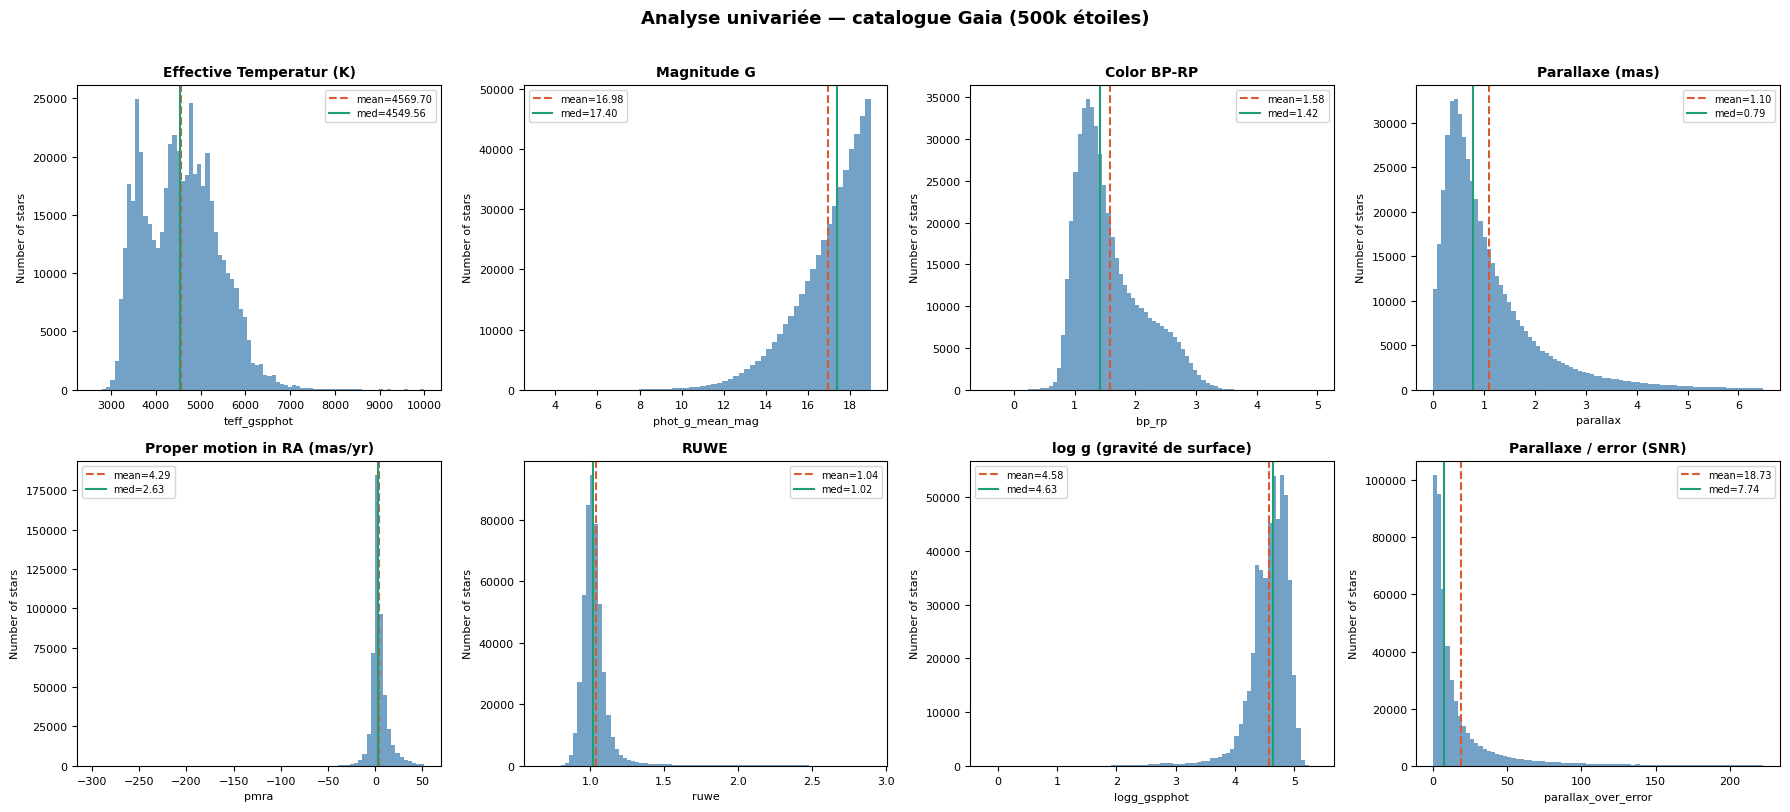

In [19]:
# Variables choisies pour leur intérêt physique ou statistique
vars_plot = {
    'teff_gspphot':        ('Effective Temperatur (K)',      False, 80),
    'phot_g_mean_mag':     ('Magnitude G',                      False, 60),
    'bp_rp':               ('Color BP-RP',                     False, 80),
    'parallax':            ('Parallaxe (mas)',                   True,  80),
    'pmra':                ('Proper motion in RA (mas/yr)',      True,  80),
    'ruwe':                ('RUWE',                              True,  80),
    'logg_gspphot':        ('log g (gravité de surface)',        False, 80),
    'parallax_over_error': ('Parallaxe / error (SNR)',          True,  80),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (col, (label, clip, bins)) in enumerate(vars_plot.items()):
    ax = axes[i]
    data = df[col].dropna()

    # Clip au 99e percentile pour les distributions très skewed
    if clip:
        data = data[data <= data.quantile(0.99)]

    ax.hist(data, bins=bins, color='steelblue', alpha=0.75, edgecolor='none')

    # Lignes moyenne et médiane
    ax.axvline(data.mean(),   color='#d85a30', lw=1.5, linestyle='--', label=f'mean={data.mean():.2f}')
    ax.axvline(data.median(), color='#1d9e75', lw=1.5, linestyle='-',  label=f'med={data.median():.2f}')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Number of stars', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.suptitle('Analyse univariée — catalogue Gaia (500k étoiles)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gaia_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Astrometry:

The parallax distribution is heavily right-skewed (skewness = 9.15), with a median of 0.80 mas and a mean pulled up to 1.18 mas by a handful of nearby bright stars, the maximum reaching 138 mas. The parallax signal-to-noise ratio (parallax_over_error) tells a similar story: a median of only 7.87 against a maximum of 3297, meaning a large fraction of the sample has poorly constrained distances. Proper motions in both RA and Dec show extreme outliers, pmra reaches ±1800 mas/yr, driving kurtosis values above 600 and 1800 respectively, a clear sign that a small population of high-velocity stars dominates the tails.

Photometry:

The G-band magnitude distribution peaks near 17–18, reflecting Gaia's sensitivity limit rather than any physical feature of the stellar population. The BP-RP colour index has a median of 1.42 and mild positive skewness (0.89), consistent with a sample dominated by cool K and M-type dwarfs. The three colour indices bp_rp, bp_g, and g_rp are by construction linearly dependent (bp_rp = bp_g + g_rp), so their dispersions are not independent. This should be kept in mind for any downstream multivariate analysis.

Data quality:

The RUWE distribution is the most extreme in the catalogue: a median of 1.02 with a standard deviation of 0.82 and a kurtosis of 855. The vast majority of sources cluster tightly below 1.4, the standard quality threshold, but the long tail up to 64 flags a non-negligible population of problematic astrometric solutions, likely unresolved binaries or sources in crowded fields. The 6.28% outlier rate by IQR confirms this. A RUWE filter (ruwe < 1.4) is strongly recommended before any scientific analysis.

Surface gravity:

logg_gspphot shows a sharp peak near 4.6 dex, firmly on the main sequence, with a pronounced left skew (−2.47) and high kurtosis (11.93) driven by a tail of giant stars at low log g. The 3.13% outlier rate is consistent with a minority giant population mixed into a predominantly dwarf sample.



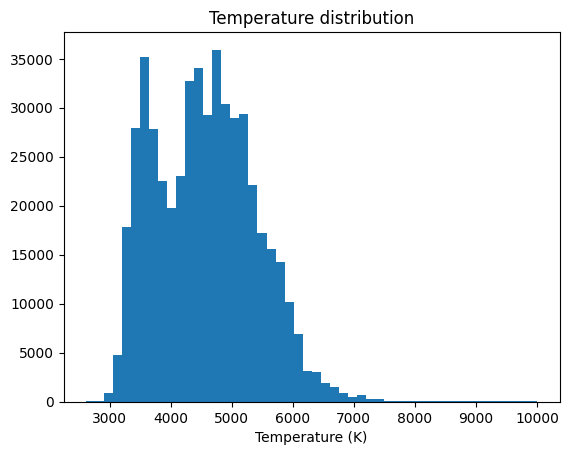

In [6]:
import matplotlib.pyplot as plt

plt.hist(df["teff_gspphot"], bins=50)
plt.title("Temperature distribution")
plt.xlabel("Temperature (K)")
plt.show()

### Temperature Distribution

The histogram of stellar temperature shows how stars are distributed across different temperature ranges. Most stars are concentrated in the lower temperature range, corresponding to cooler stars such as red dwarfs. Fewer stars appear at higher temperatures, which correspond to massive and hotter stars.

This distribution reflects the natural stellar population in the Milky Way, where cooler stars are more common. Understanding this distribution helps identify whether the dataset is balanced and suitable for machine learning classification.

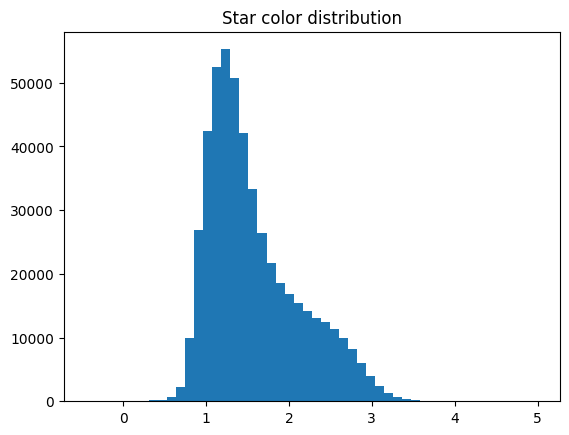

In [7]:
plt.hist(df["bp_rp"], bins=50)
plt.title("Star color distribution")
plt.show()

### Color Index Distribution (BP − RP)

The BP−RP color index measures the difference between blue and red magnitudes and is strongly correlated with stellar temperature. Lower values correspond to blue, hotter stars, while higher values correspond to red, cooler stars.

The distribution of BP−RP values helps identify different stellar populations and provides an initial view of how stars are grouped based on their temperature and spectral characteristics.

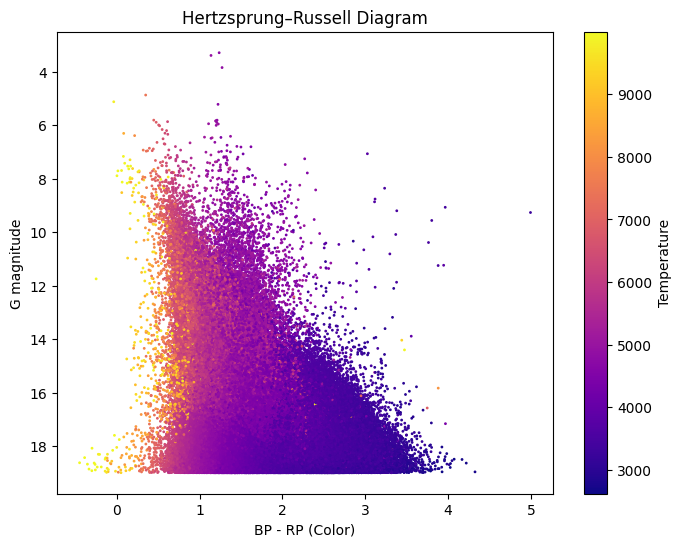

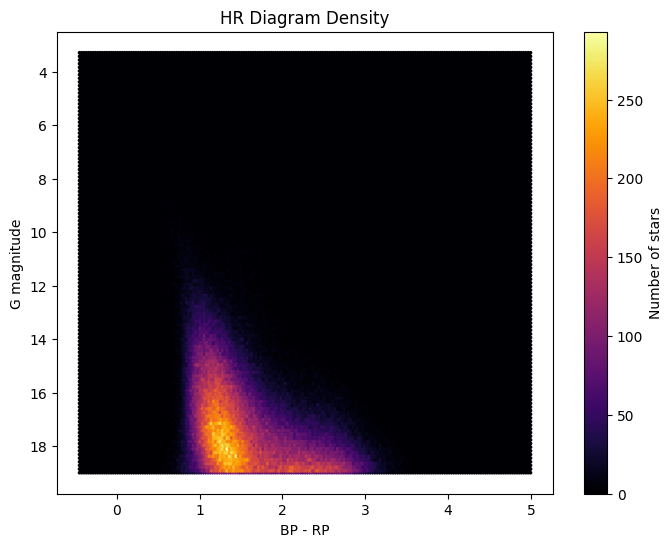

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    c=df["teff_gspphot"],
    s=1,
    cmap="plasma"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP (Color)")
plt.ylabel("G magnitude")
plt.title("Hertzsprung–Russell Diagram")

cbar = plt.colorbar()
cbar.set_label("Temperature")

plt.show()
plt.figure(figsize=(8,6))

plt.hexbin(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    gridsize=200,
    cmap="inferno"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("G magnitude")
plt.title("HR Diagram Density")

plt.colorbar(label="Number of stars")

plt.show()

### Hertzsprung–Russell Diagram

The Hertzsprung–Russell (HR) diagram plots stellar color (BP−RP) against magnitude. This diagram is one of the most important tools in astrophysics because it reveals the structure of stellar populations.

Distinct regions can be observed:

- Main sequence stars form a diagonal band
- Giant stars appear above the main sequence
- Cooler stars appear toward the right side
- Hotter stars appear toward the left side

The presence of these structures confirms that the Gaia dataset contains meaningful astrophysical information and that machine learning methods should be able to identify these populations automatically.

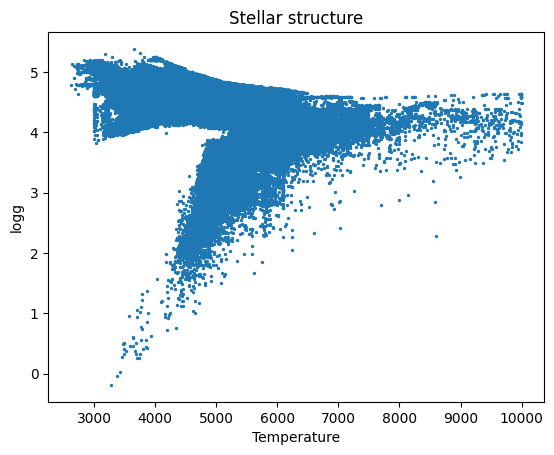

In [9]:
plt.scatter(
df["teff_gspphot"],
df["logg_gspphot"],
s=2
)

plt.xlabel("Temperature")
plt.ylabel("logg")
plt.title("Stellar structure")
plt.show()

### Temperature vs Surface Gravity

This plot shows the relationship between stellar temperature and surface gravity. Surface gravity is a key indicator of stellar type:

- High surface gravity corresponds to main sequence stars
- Low surface gravity corresponds to giant stars
- Intermediate values correspond to subgiants

This visualization allows us to observe how different stellar populations separate in parameter space. These separations provide a strong foundation for supervised machine learning classification.


<Axes: >

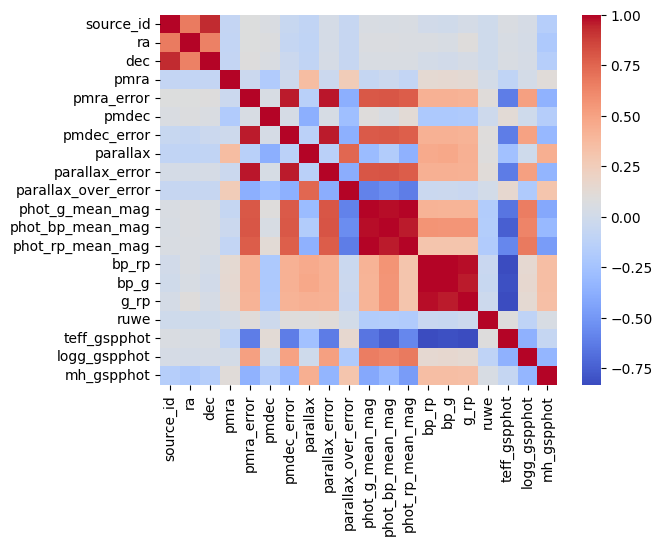

In [10]:
import seaborn as sns

sns.heatmap(df.corr(), cmap="coolwarm")

### Correlation Matrix Analysis

The correlation matrix shows the relationships between the main stellar variables extracted from the Gaia dataset. Strong correlations appear between the photometric magnitudes (phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag), which is expected since they measure brightness in different wavelength bands.

The BP−RP color index is strongly correlated with effective temperature (teff_gspphot), confirming that color is a good proxy for stellar temperature. This is consistent with astrophysical theory, where redder stars are cooler and bluer stars are hotter.

Surface gravity (logg_gspphot) shows moderate correlations with magnitude and temperature, reflecting the structural differences between main sequence stars and giant stars. Giants typically have lower surface gravity and higher luminosity.

Distance-related variables show correlations with extinction parameters (ag_gspphot, azero_gspphot, ebpminrp_gspphot), which is expected since more distant stars are more affected by interstellar dust.

Overall, the correlation matrix confirms that the selected Gaia variables capture meaningful physical relationships between stellar properties. These correlations indicate that machine learning models should be able to learn the structure of stellar populations and classify stars based on their physical characteristics.

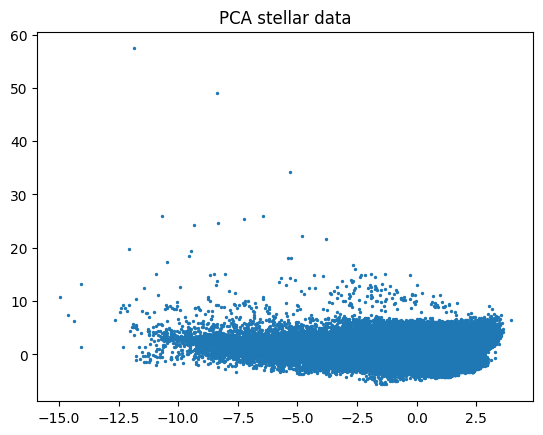

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
"phot_g_mean_mag",
"phot_bp_mean_mag",
"phot_rp_mean_mag",
"bp_rp",
"parallax",
"teff_gspphot",
"logg_gspphot",
"mh_gspphot"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], s=2)
plt.title("PCA stellar data")
plt.show()

PCA with all variables

In [28]:
#Bloc 1 — Variance expliquée & Scree plot

#Préparation des données
pca_cols = [
    'ra', 'dec',
    'pmra', 'pmra_error', 'pmdec', 'pmdec_error',
    'parallax', 'parallax_error', 'parallax_over_error',
    'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
    'bp_rp', 'bp_g', 'g_rp',
    'ruwe', 'logg_gspphot', 'mh_gspphot'
]

# Clip au 99e percentile pour limiter l'influence des outliers
df_pca = df[pca_cols].copy()
for col in pca_cols:
    p99 = df_pca[col].quantile(0.99)
    p01 = df_pca[col].quantile(0.01)
    df_pca[col] = df_pca[col].clip(p01, p99)

# Standardisation obligatoire avant PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)
#PCA + tableau de variance
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

var_exp   = pca.explained_variance_ratio_ * 100
var_cumul = np.cumsum(var_exp)

df_variance = pd.DataFrame({
    'PC'          : [f'PC{i+1}' for i in range(10)],
    'var_exp_%'   : var_exp.round(2),
    'var_cumul_%' : var_cumul.round(2)
})
display(df_variance)


,PC,var_exp_%,var_cumul_%
0,PC1,39.98,39.98
1,PC2,21.02,61.00
2,PC3,9.46,70.46
3,PC4,6.36,76.82
4,PC5,6.21,83.03
5,PC6,4.63,87.67
6,PC7,3.92,91.58
7,PC8,2.96,94.55
8,PC9,2.31,96.86
9,PC10,1.75,98.61


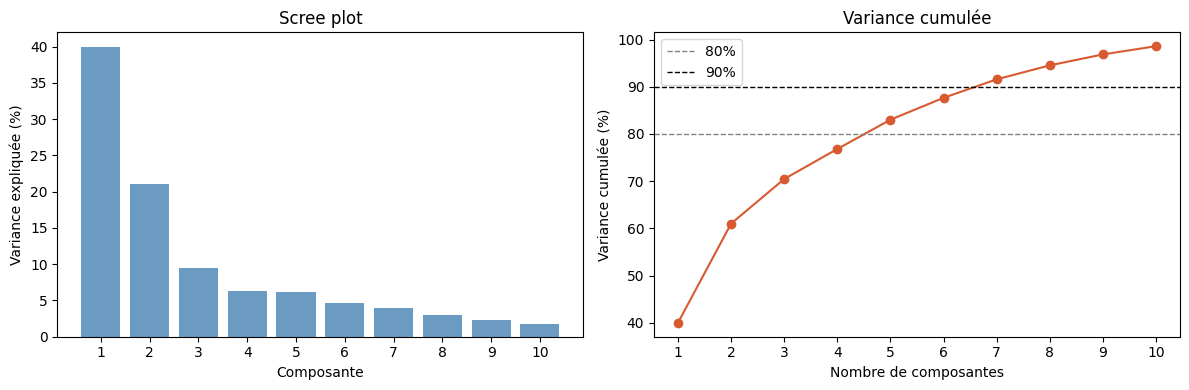

In [29]:
#Scree plot + variance cumulée
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 11), var_exp, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, 11))

axes[1].plot(range(1, 11), var_cumul, marker='o', color='#d85a30')
axes[1].axhline(80, color='gray', linestyle='--', lw=1, label='80%')
axes[1].axhline(90, color='black', linestyle='--', lw=1, label='90%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée')
axes[1].legend()
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

Principal Component Analysis — Gaia Catalogue (500,000 sources, 18 variables)
The PCA was conducted on 18 astrometric, photometric, and astrophysical variables after standardisation and winsorisation at the 1st and 99th percentiles to limit the influence of extreme outliers. Ten components were extracted, collectively explaining 98.61% of the total variance.
PC1 (39.98%) is by far the dominant component, driven by the three photometric magnitudes (G, BP, RP) and the three astrometric uncertainty variables (parallax error, pmra error, pmdec error). It captures the fundamental trade-off between stellar brightness and measurement precision: faint stars are harder to measure, so their astrometric errors are systematically larger. PC1 can be interpreted as a brightness-and-quality axis.
PC2 (21.02%) is anchored by parallax, the three colour indices (BP-RP, BP-G, G-RP), and metallicity (mh_gspphot). It separates nearby, red, metal-rich stars from distant, bluer ones. PC2 is essentially a distance-and-colour axis, reflecting the well-known correlation between proximity and spectral type in a magnitude-limited survey.
PC3 (9.46%) is almost entirely defined by right ascension and declination. It carries no physical stellar information — it simply reflects the spatial footprint of the catalogue on the sky. The fact that sky position emerges as an independent component confirms that the spatial sampling of this Gaia subset is not uniform.
PC4 (6.36%) is dominated by RUWE alone. This component isolates sources with poor astrometric fits — unresolved binaries, crowded-field detections, or extended sources. Its independence from the other components confirms that astrometric quality issues are not correlated with brightness or colour in this sample.
PC5 (6.21%) picks up residual variance in the proper motion components (pmra, pmdec) not captured by PC2. It likely reflects the kinematic diversity of the sample — distinct stellar populations with different velocity dispersions, such as thin disc, thick disc, and halo stars.
PC6 to PC10 (4.63% down to 1.75%) collectively account for the remaining 15.58% of variance. They capture increasingly specific and residual signals: fine-grained correlations between error terms, subtle colour-metallicity relationships, and noise. While statistically real, these components are difficult to interpret physically and are unlikely to be useful for downstream analyses such as clustering or classification.
Overall, the first four components alone explain 76.82% of the variance and each carry a clear physical interpretation. Adding PC5 brings the total to 83.03%, which is a reasonable threshold for most applications. The remaining components can safely be discarded.

,PC1,PC2,PC3,PC4
ra,0.033,-0.058,0.680,0.103
dec,0.028,-0.069,0.662,0.140
pmra,-0.014,0.183,-0.137,0.218
pmra_error,0.341,-0.022,-0.023,0.238
pmdec,0.020,-0.249,0.076,-0.248
pmdec_error,0.337,-0.008,-0.135,0.210
parallax,-0.060,0.446,-0.014,0.183
parallax_error,0.342,-0.016,-0.069,0.226
parallax_over_error,-0.231,0.250,-0.011,0.214
phot_g_mean_mag,0.360,-0.079,-0.027,-0.098


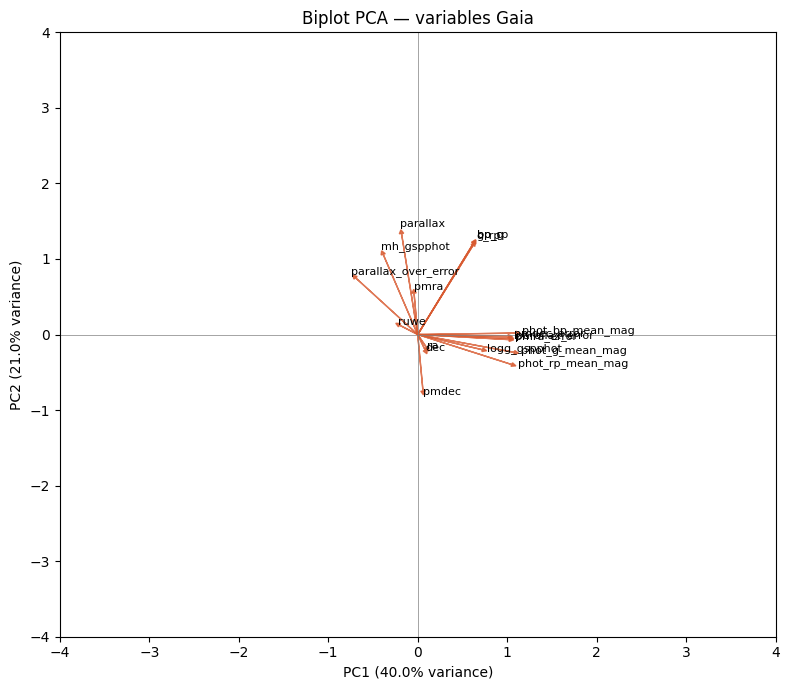

In [27]:
loadings = pd.DataFrame(
    pca.components_[:4].T,
    index=pca_cols,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
).round(3)
display(loadings)
#Biplot PC1 vs PC2
fig, ax = plt.subplots(figsize=(8, 7))

for i, var in enumerate(pca_cols):
    ax.arrow(0, 0,
             pca.components_[0, i] * 3,
             pca.components_[1, i] * 3,
             head_width=0.05, head_length=0.05,
             fc='#d85a30', ec='#d85a30', alpha=0.8)
    ax.text(pca.components_[0, i] * 3.2,
            pca.components_[1, i] * 3.2,
            var, fontsize=8)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance)')
ax.set_title('Biplot PCA — variables Gaia')
plt.tight_layout()
plt.show()

Biplot Interpretation: PC1 vs PC2

The biplot displays the projection of the 18 variables onto the first two principal components, which together account for 61% of the total variance. Each arrow represents one variable: its direction indicates how it contributes to PC1 and PC2, and its length reflects the strength of that contribution — longer arrows are better represented in this two-dimensional space.

The photometric and error cluster (right, PC1 axis)
The most striking feature of the biplot is the tight bundle of arrows pointing horizontally to the right. This group includes the three magnitudes (G, BP, RP) and the three astrometric error terms (parallax error, pmra error, pmdec error), all nearly parallel to the PC1 axis. Their alignment confirms that these six variables are strongly correlated with one another and carry essentially the same information: stars that are faint are also poorly measured. The near-perfect overlap of the three magnitude arrows further illustrates the redundancy already identified in the univariate analysis.

The distance and colour cluster (upper left, PC2 axis)
A second group of arrows points upward and to the left, dominated by parallax, the three colour indices (BP-RP, BP-G, G-RP), and metallicity (mh_gspphot). These variables load positively on PC2 and negatively or weakly on PC1, meaning they carry information that is largely orthogonal to brightness. The three colour indices are almost perfectly superimposed, which is expected given that BP-RP = BP-G + G-RP by construction — they are linearly dependent and only one needs to be retained in any multivariate model.

Proper motion in declination (bottom, negative PC2)
The arrow for pmdec points downward, nearly opposite to the parallax-colour cluster. This orthogonality is physically meaningful: the motion of a star across the sky in declination is independent of how bright, red, or close it is. pmra, by contrast, has a short upward arrow, suggesting it carries a weak positive correlation with the distance-colour axis — possibly a kinematic signature of nearby red stars having higher tangential velocities on average.

Variables poorly represented in this plane
Several arrows are notably short: ra, dec, and ruwe. This does not mean these variables are unimportant — it means their variance is captured by other components not shown here. As established earlier, sky position dominates PC3 and RUWE defines PC4 almost entirely. Their short arrows in the PC1-PC2 plane are therefore expected and confirm the orthogonality of the component structure.

Overall, the biplot clearly reveals three independent dimensions in the Gaia data: a brightness-quality axis (PC1), a distance-colour axis (PC2), and by inference a sky-position axis and an astrometric-quality axis captured in higher components. This structure strongly supports reducing the 18 original variables to 4 or 5 principal components for any subsequent analysis.